In [1]:
import pandas as pd
import numpy as np
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # make "GPU 1" be seen as cuda:0 inside this process

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

random_seed_number = 45
np.random.seed(random_seed_number)

# Specify the file path
file_path = "../Machine_Learning/data_all.xlsx"

# Read the data from the 'batch1' sheet into a pandas DataFrame
data = pd.read_excel(file_path, sheet_name="batch1").dropna()

# Display the first few rows to check if the data was loaded correctly
print(data.head())

                     exp      对位选择性      间位选择性      邻位选择性     ton
1  1-I,F,Y,G,K,V,A,N,M,D  20.475293  33.274272  46.250436   6.969
2  2-L,V,Q,Y,K,N,C,F,P,E  21.367940  31.454554  47.177505   4.455
3  3-N,E,I,G,K,Y,I,V,N,Y  21.722533  32.787287  45.490180   2.721
4  4-D,E,T,I,K,I,Q,Y,A,M  20.138117  32.318466  47.543417  12.690
5  5-N,Q,I,Q,K,P,Y,V,D,Y  21.499640  30.798048  47.702312   4.267


In [2]:
X = np.array(
    [i.replace("-重复", "").split("-")[1].split(",") for i in data["exp"]]
)  # 把重复数据的“重复”删除，拆分为列表

y = data["ton"].values

unique_X = np.unique(X, axis=0)  # x=多肽序列并去重
average_Y = np.array(
    [y[(X == val).all(axis=1)].mean() for val in unique_X]
    )  # y平均

In [3]:
len(y)

234

In [4]:
import torch
import esm

torch.manual_seed(random_seed_number)

# Load ESM-2 model
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model = model.cuda()
model.eval()  # disables dropout for deterministic results

# Prepare data (first 2 sequences from ESMStructuralSplitDataset superfamily / 4)
data = [(f"protein{count}", "".join(unique_X[count])) for count in range(len(unique_X))]
batch_labels, batch_strs, batch_tokens = batch_converter(data)
batch_lens = (batch_tokens != alphabet.padding_idx).sum(1)

# Extract per-residue representations (on CPU)
with torch.no_grad():
    results = model(batch_tokens.cuda(), repr_layers=[33], return_contacts=True)
token_representations = results["representations"][33]

sequence_representations = []
for i, tokens_len in enumerate(batch_lens):
    sequence_representations.append(
        token_representations[i, 1 : tokens_len - 1].mean(0).cpu()
    )

In [5]:
Xs = np.array(sequence_representations)
ys = average_Y

In [6]:
train_size = 0.8
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    Xs, ys, train_size=train_size, random_state=random_seed_number
)

In [7]:
Xs_train.shape, Xs_test.shape, len(ys_train), len(ys_test)

((185, 1280), (47, 1280), 185, 47)

In [8]:
num_pca_components = 30
pca = PCA(num_pca_components)
Xs_train_pca = pca.fit_transform(Xs_train)

In [9]:
import matplotlib.pyplot as plt
import numpy as np

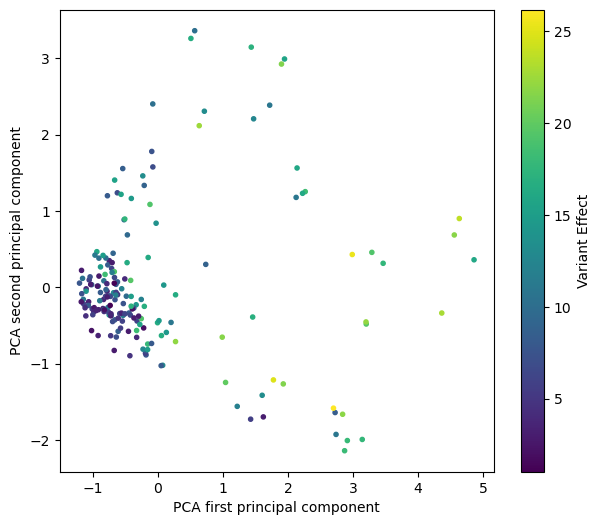

In [10]:
fig_dims = (7, 6)
fig, ax = plt.subplots(figsize=fig_dims)
sc = ax.scatter(Xs_train_pca[:, 0], Xs_train_pca[:, 1], c=ys_train, marker=".")
ax.set_xlabel("PCA first principal component")
ax.set_ylabel("PCA second principal component")
plt.colorbar(sc, label="Variant Effect")

In [11]:
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyRegressor
from sklearn.metrics import r2_score, mean_squared_error

best_modesl = []

for i in range(10):

    X_train, X_test, y_train, y_test = train_test_split(
        Xs_train, ys_train, test_size=0.2, random_state=123 + i
    )

    clf = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
    models, predictions = clf.fit(X_train, X_test, y_train, y_test)
    display(predictions)
    
    # get the best model for now 
    best_model = clf.models[predictions.index[-1]]
    # calculate the metric 
    r2 = r2_score(ys_test, best_model.predict(Xs_test))
    RMSE =np.sqrt(
            mean_squared_error(
                ys_test, best_model.predict(Xs_test)
            )
        )
    # if r2 is larger than 0.50, append the models
    if r2>0.50:
        best_modesl.append(best_model)
        
    display(r2,RMSE)

100%|██████████| 42/42 [01:01<00:00,  1.46s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011595 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 65280
[LightGBM] [Info] Number of data points in the train set: 148, number of used features: 1280
[LightGBM] [Info] Start training from score 10.725122
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
SGDRegressor,739236209444678664192.00,-25544717904143898902528.00,998873606554.18,0.04
OrthogonalMatchingPursuit,1.16,-4.40,14.52,0.05
KernelRidge,1.11,-2.70,12.03,0.04
GaussianProcessRegressor,1.10,-2.50,11.69,0.05
DummyRegressor,1.03,-0.02,6.31,0.03
QuantileRegressor,1.03,-0.00,6.25,0.27
PoissonRegressor,1.03,0.00,6.25,0.12
LinearRegression,1.03,0.09,5.97,0.05
TransformedTargetRegressor,1.03,0.09,5.97,0.05


0.5935104763448236

3.8196611079370943

...

100%|██████████| 42/42 [00:52<00:00,  1.25s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011726 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 65280
[LightGBM] [Info] Number of data points in the train set: 148, number of used features: 1280
[LightGBM] [Info] Start training from score 10.597466
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
SGDRegressor,1836098007815522615296.00,-63447386714514177130496.00,1358182584960.76,0.04
KernelRidge,1.16,-4.63,12.80,0.04
GaussianProcessRegressor,1.14,-3.71,11.71,0.07
OrthogonalMatchingPursuit,1.12,-3.04,10.84,0.05
DecisionTreeRegressor,1.03,-0.18,5.85,0.20
QuantileRegressor,1.03,-0.07,5.58,0.22
ExtraTreeRegressor,1.03,-0.01,5.41,0.09
DummyRegressor,1.03,-0.00,5.40,0.03
LinearSVR,1.03,0.08,5.17,0.34


0.5466813402114015

4.033684740571273

In [12]:
best_models = best_modesl

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import copy

from matplotlib import pyplot as plt 
import numpy as np
import pandas as pd 
from copy import copy

plt.rcParams["font.family"] = "Arial"
data = pd.read_excel("../Machine_Learning/data_all.xlsx")

data_all = [] 
for batch_num in range(19):
    start_index = (data[data["ton"].isna()].index)[2*batch_num]
    end_index = (data[data["ton"].isna()].index)[2*batch_num + 1]
    print(data.iloc[start_index : end_index])
    data_all.append(
        data.iloc[start_index + 1 : end_index]
    )

print(data.iloc[(data[data["ton"].isna()].index)[-1]::])

data_all.append(
    data.iloc[(data[data["ton"].isna()].index)[-1] + 1::]
)

data_all_origin = copy(data_all)
data_all = pd.concat(data_all)
data = data_all

                       exp  对位选择性  间位选择性  邻位选择性   ton
0                    第一轮随机    NaN    NaN    NaN   NaN
1    1-I,F,Y,G,K,V,A,N,M,D  20.48  33.27  46.25  6.97
2    2-L,V,Q,Y,K,N,C,F,P,E  21.37  31.45  47.18  4.46
3    3-N,E,I,G,K,Y,I,V,N,Y  21.72  32.79  45.49  2.72
4    4-D,E,T,I,K,I,Q,Y,A,M  20.14  32.32  47.54 12.69
5    5-N,Q,I,Q,K,P,Y,V,D,Y  21.50  30.80  47.70  4.27
6    6-N,F,M,A,K,P,N,E,N,Y  21.99  32.47  45.54  2.79
7    7-T,Y,N,Q,K,E,T,G,T,D  20.54  32.45  47.00  6.47
8    8-T,D,V,D,K,F,S,N,Y,D  20.28  32.51  47.21  8.85
9    9-N,V,E,E,K,T,P,T,Y,Y  20.84  34.29  44.87  3.04
10  10-F,F,Y,T,K,D,S,N,Y,D  20.38  32.84  46.78  8.79
11  11-P,V,H,C,K,S,D,I,E,S  20.63  30.27  49.10 14.45
12  12-N,Q,F,L,K,H,D,C,D,G  21.62  28.47  49.91 10.83
13  13-P,P,N,C,K,H,M,C,C,V  20.84  29.37  49.78 14.58
14  14-P,P,M,F,K,D,G,H,I,P  20.98  30.19  48.84 10.09
15  15-P,T,G,G,K,D,D,C,Q,N  20.29  32.10  47.61  7.12
16  16-M,V,M,C,K,G,P,F,P,P  20.56  30.62  48.82 15.62
17  17-F,F,I,T,K,D,S,N,Y,E  

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

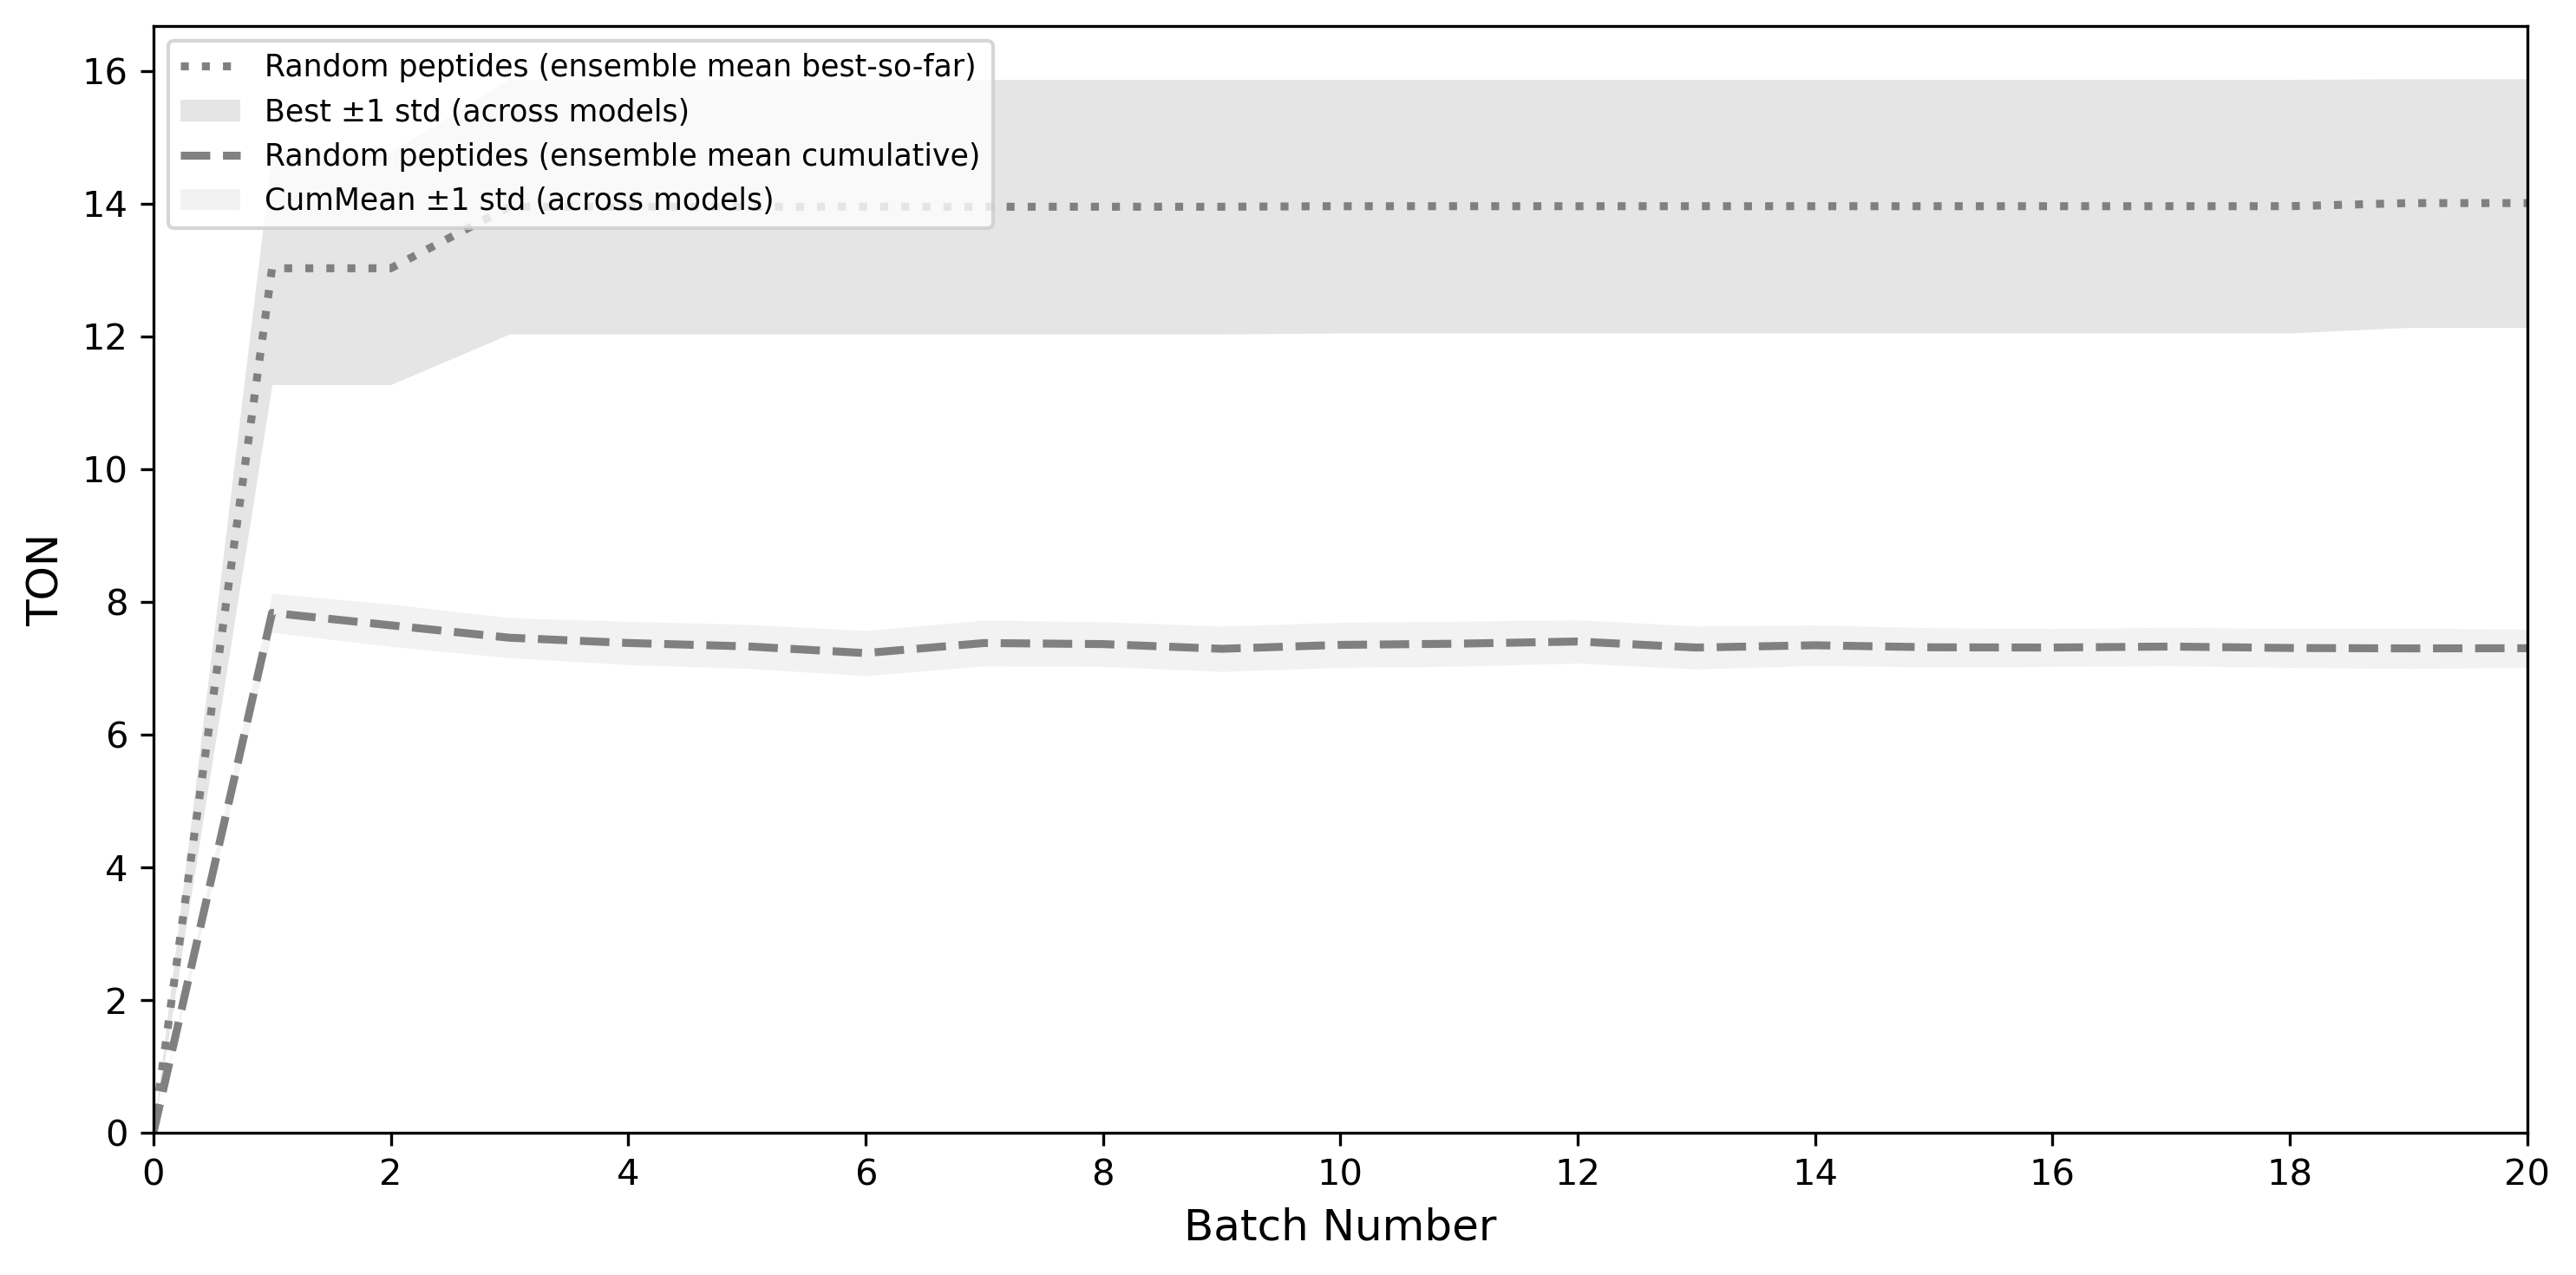

In [14]:
import numpy as np
import torch
import esm
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ============================================================
# 0) Budgets: exactly match AL batches
batch_sizes = [len(df) for df in data_all_origin]   # batch 1..N
n_batches   = len(batch_sizes)
x = np.arange(n_batches + 1)  # prepend 0 for plotting

# ============================================================
# 1) Random peptide generator (len=10, pos5 fixed to K)
AA20 = np.array(list("ACDEFGHIKLMNPQRSTVWY"), dtype="<U1")

def sample_random_peptide_strs(n, L=10, fixed_pos_1based=5, fixed_aa="K",
                               alphabet=AA20, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    X = rng.choice(alphabet, size=(n, L))
    X[:, fixed_pos_1based - 1] = fixed_aa
    return ["".join(row.tolist()) for row in X]

# ============================================================
# 2) ESM embedding (mean over residues, same as your code)
def esm2_embed_sequences(
    seqs,
    model,
    alphabet,
    batch_converter,
    layer=33,
    device="cuda",
    batch_size=64,
):
    model.eval()
    reps = []
    data = [(f"seq{i}", s) for i, s in enumerate(seqs)]

    with torch.no_grad():
        for start in range(0, len(data), batch_size):
            chunk = data[start:start + batch_size]
            _, _, tokens = batch_converter(chunk)
            tokens = tokens.to(device)

            lens = (tokens != alphabet.padding_idx).sum(1)  # includes BOS/EOS
            out = model(tokens, repr_layers=[layer], return_contacts=False)
            token_reps = out["representations"][layer]      # (B, T, C)

            for i, Ltok in enumerate(lens.tolist()):
                vec = token_reps[i, 1:Ltok-1].mean(0).detach().cpu()
                reps.append(vec)

    X = torch.stack(reps, dim=0).numpy().astype(np.float32)
    return X

def build_random_embedding_pool(
    n_pool,
    esm_model,
    alphabet,
    batch_converter,
    seed=0,
    L=10,
    fixed_pos_1based=5,
    fixed_aa="K",
    layer=33,
    device="cuda",
    batch_size=64,
):
    rng = np.random.default_rng(seed)
    seqs = sample_random_peptide_strs(
        n_pool, L=L, fixed_pos_1based=fixed_pos_1based, fixed_aa=fixed_aa, rng=rng
    )
    return esm2_embed_sequences(
        seqs, esm_model, alphabet, batch_converter,
        layer=layer, device=device, batch_size=batch_size
    )

# ============================================================
# 3) Helper: get ensemble of models for batch i
# Supports:
#   - best_models[i] is a list/tuple of models (ensemble per batch)
#   - best_models is a flat list of models (global ensemble)
def get_models_for_batch(best_models, batch_i_1based):
    # per-batch ensemble
    if isinstance(best_models, (list, tuple)) and len(best_models) > 0:
        if isinstance(best_models[0], (list, tuple)):  # nested: per-batch ensembles
            return best_models[batch_i_1based - 1]
        else:
            # flat: global ensemble
            return best_models
    raise ValueError("best_models format not recognized.")

# ============================================================
# 4) Random baseline where mean/std come from the ensemble models
def random_baseline_mean_std_from_models(
    best_models,
    batch_sizes,
    Xpool,
    seed=0,
    replace=True,
):
    rng = np.random.default_rng(seed)
    pool_N = Xpool.shape[0]

    # store curves for each model inside each batch ensemble:
    # If per-batch ensembles, number of models may vary; we handle that by aggregating per batch.
    rand_best_mean = [0.0]
    rand_best_std  = [0.0]
    rand_cum_mean  = [0.0]
    rand_cum_std   = [0.0]
    rand_bmean_mean = [0.0]
    rand_bmean_std  = [0.0]

    # For fairness: use ONE random draw per batch, shared across models (so variability is from models only)
    seen_X = []

    for bi, n in enumerate(batch_sizes, start=1):
        if (not replace) and (n > pool_N):
            raise ValueError(f"POOL too small for replace=False: pool_N={pool_N}, batch_n={n}")

        idx = rng.choice(pool_N, size=n, replace=replace)
        Xnew = Xpool[idx]
        seen_X.append(Xnew)

        X_seen = np.concatenate(seen_X, axis=0)

        models = get_models_for_batch(best_models, bi)

        # compute each model's batch stats
        batch_means = []
        cum_means   = []
        best_sofar  = []

        for m in models:
            y_new  = np.asarray(m.predict(Xnew), dtype=float).ravel()
            y_seen = np.asarray(m.predict(X_seen), dtype=float).ravel()

            batch_means.append(y_new.mean())
            cum_means.append(y_seen.mean())
            best_sofar.append(y_seen.max())

        # aggregate across models -> mean & std (what you asked for)
        rand_bmean_mean.append(float(np.mean(batch_means)))
        rand_bmean_std.append(float(np.std(batch_means, ddof=1) if len(batch_means) > 1 else 0.0))

        rand_cum_mean.append(float(np.mean(cum_means)))
        rand_cum_std.append(float(np.std(cum_means, ddof=1) if len(cum_means) > 1 else 0.0))

        rand_best_mean.append(float(np.mean(best_sofar)))
        rand_best_std.append(float(np.std(best_sofar, ddof=1) if len(best_sofar) > 1 else 0.0))

    return {
        "best_mean": np.array(rand_best_mean),
        "best_std":  np.array(rand_best_std),
        "cum_mean":  np.array(rand_cum_mean),
        "cum_std":   np.array(rand_cum_std),
        "bmean_mean": np.array(rand_bmean_mean),
        "bmean_std":  np.array(rand_bmean_std),
    }

# ============================================================
# 5) RUN: load ESM once, build pool once, compute baseline
random_seed_number = 0
torch.manual_seed(random_seed_number)

esm_model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
device = "cuda" if torch.cuda.is_available() else "cpu"
esm_model = esm_model.to(device).eval()

POOL_SIZE = 10000  # increase if you want smoother random baseline
Xpool = build_random_embedding_pool(
    n_pool=POOL_SIZE,
    esm_model=esm_model,
    alphabet=alphabet,
    batch_converter=batch_converter,
    seed=random_seed_number,
    L=10,
    fixed_pos_1based=5,
    fixed_aa="K",
    layer=33,
    device=device,
    batch_size=64,
)

baseline = random_baseline_mean_std_from_models(
    best_models=best_models,
    batch_sizes=batch_sizes,
    Xpool=Xpool,
    seed=random_seed_number,
    replace=True,
)

# choose which baseline curves to plot
best_mean = baseline["best_mean"]
best_std  = baseline["best_std"]

cum_mean  = baseline["cum_mean"]
cum_std   = baseline["cum_std"]

# ============================================================
# Plot: random baseline (best-so-far + cumulative mean), each with ±1 std across models
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# Best-so-far
ax.plot(x, best_mean, linestyle=':', linewidth=2.2, color='gray',
        label="Random peptides (ensemble mean best-so-far)")
ax.fill_between(x, best_mean - best_std, best_mean + best_std,
                color='gray', alpha=0.20, linewidth=0, label="Best ±1 std (across models)")

# Cumulative mean
ax.plot(x, cum_mean, linestyle='--', linewidth=2.2, color='gray',
        label="Random peptides (ensemble mean cumulative)")
ax.fill_between(x, cum_mean - cum_std, cum_mean + cum_std,
                color='gray', alpha=0.10, linewidth=0, label="CumMean ±1 std (across models)")

ax.set_xlabel("Batch Number", fontsize=12)
ax.set_ylabel("TON", fontsize=12)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlim(0, len(x) - 1)
ax.set_ylim(bottom=0)
ax.legend(loc="upper left", fontsize='small')

plt.tight_layout()
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

findfont: Font family 'Arial' not found.


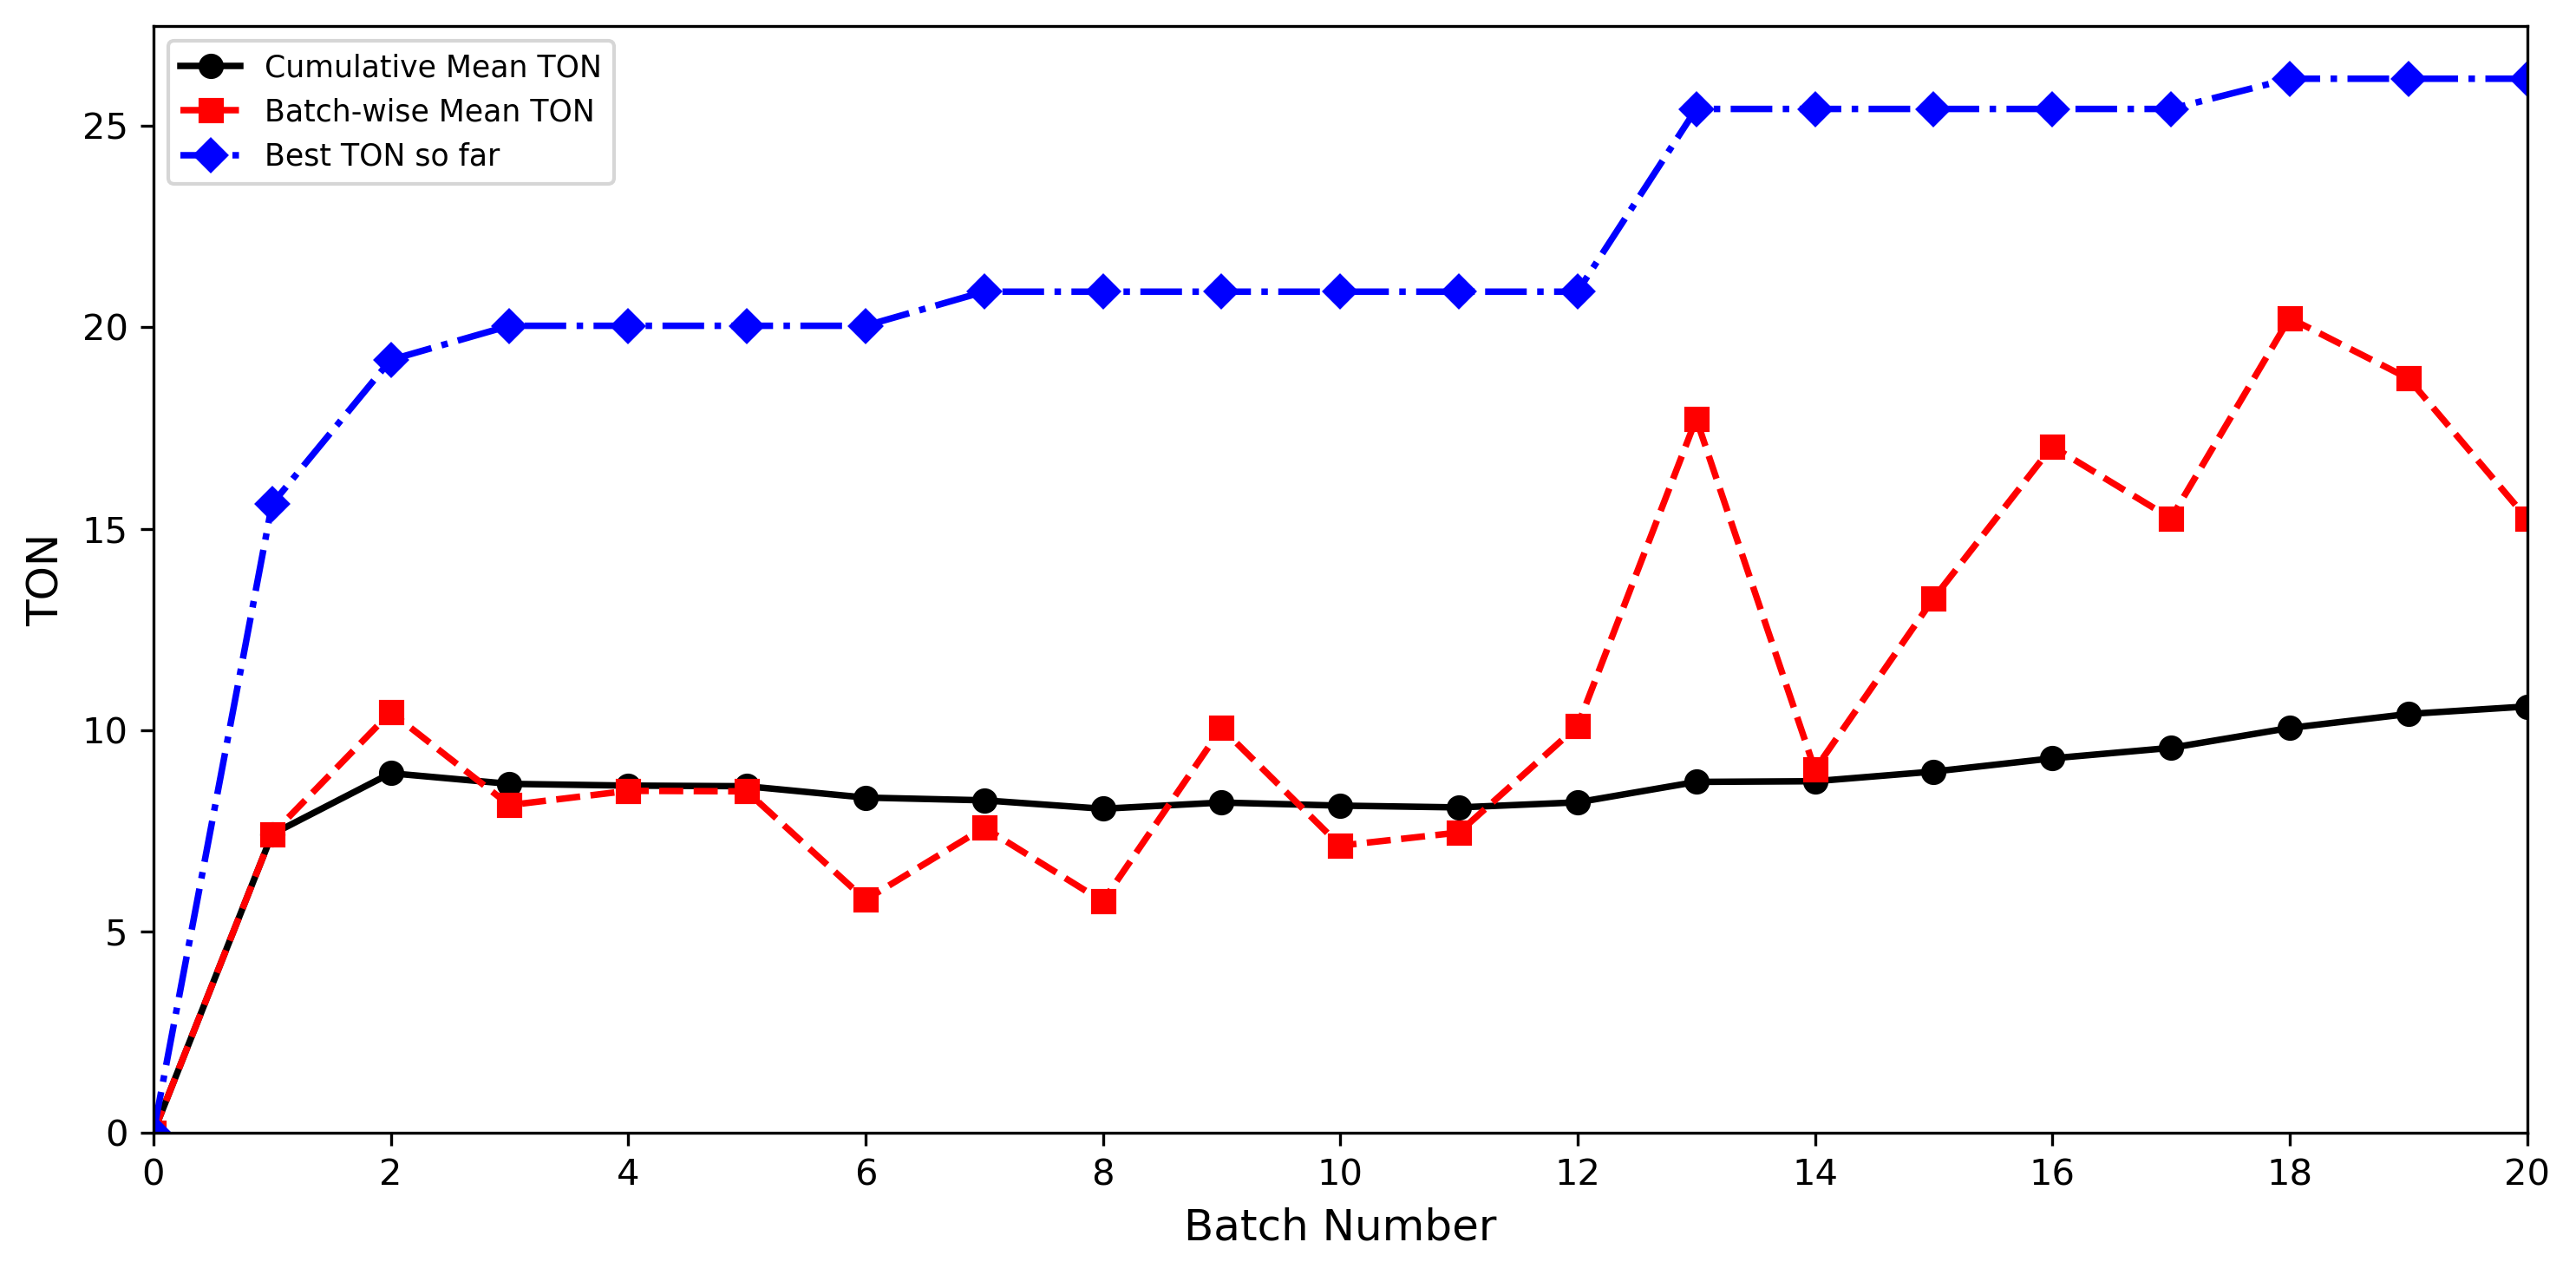

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ——————————————————————————————————————————————
# 1) Compute cumulative & batch‑wise stats + running max
mean_ton_all   = []
best_ton_all   = []
mean_ton_batch = []

for i in range(1, len(data_all_origin) + 1):
    data_temp = pd.concat(data_all_origin[:i])
    tons_temp = data_temp["ton"].values
    mean_ton_all.append(tons_temp.mean())
    best_ton_all.append(tons_temp.max())

for df in data_all_origin:
    tons_batch = df["ton"].values
    mean_ton_batch.append(tons_batch.mean())
    
mean_ton_all = [0] + mean_ton_all
mean_ton_all   = np.array(mean_ton_all)

best_ton_all = [0] + best_ton_all
best_ton_all   = np.array(best_ton_all)

mean_ton_batch = [0] + mean_ton_batch
mean_ton_batch = np.array(mean_ton_batch)
batch_count    = len(mean_ton_all)

# 2) X axis: batches numbered 0…N-1
x = np.arange(batch_count)

# ——————————————————————————————————————————————
# 3) Single-axis plot without error bars
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# Cumulative mean TON (black)
ax.plot(
    x,
    mean_ton_all,
    marker='o',
    linestyle='-',
    color='black',
    linewidth=1.8,
    markersize=6,
    label="Cumulative Mean TON"
)

# Batch‑wise mean TON (red)
ax.plot(
    x,
    mean_ton_batch,
    marker='s',
    linestyle='--',
    color='red',
    linewidth=1.8,
    markersize=6,
    label="Batch-wise Mean TON"
)

# Best TON so far (blue)
ax.plot(
    x,
    best_ton_all,
    marker='D',
    linestyle='-.',
    color='blue',
    linewidth=1.8,
    markersize=6,
    label="Best TON so far"
)

# Styling
ax.set_xlabel("Batch Number", fontsize=12)
ax.set_ylabel("TON", fontsize=12)

# Integer x‑ticks and axis limits
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlim(0, batch_count - 1)
ax.set_ylim(bottom=0)

# Legend
ax.legend(loc="upper left", fontsize='small')

plt.tight_layout()
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

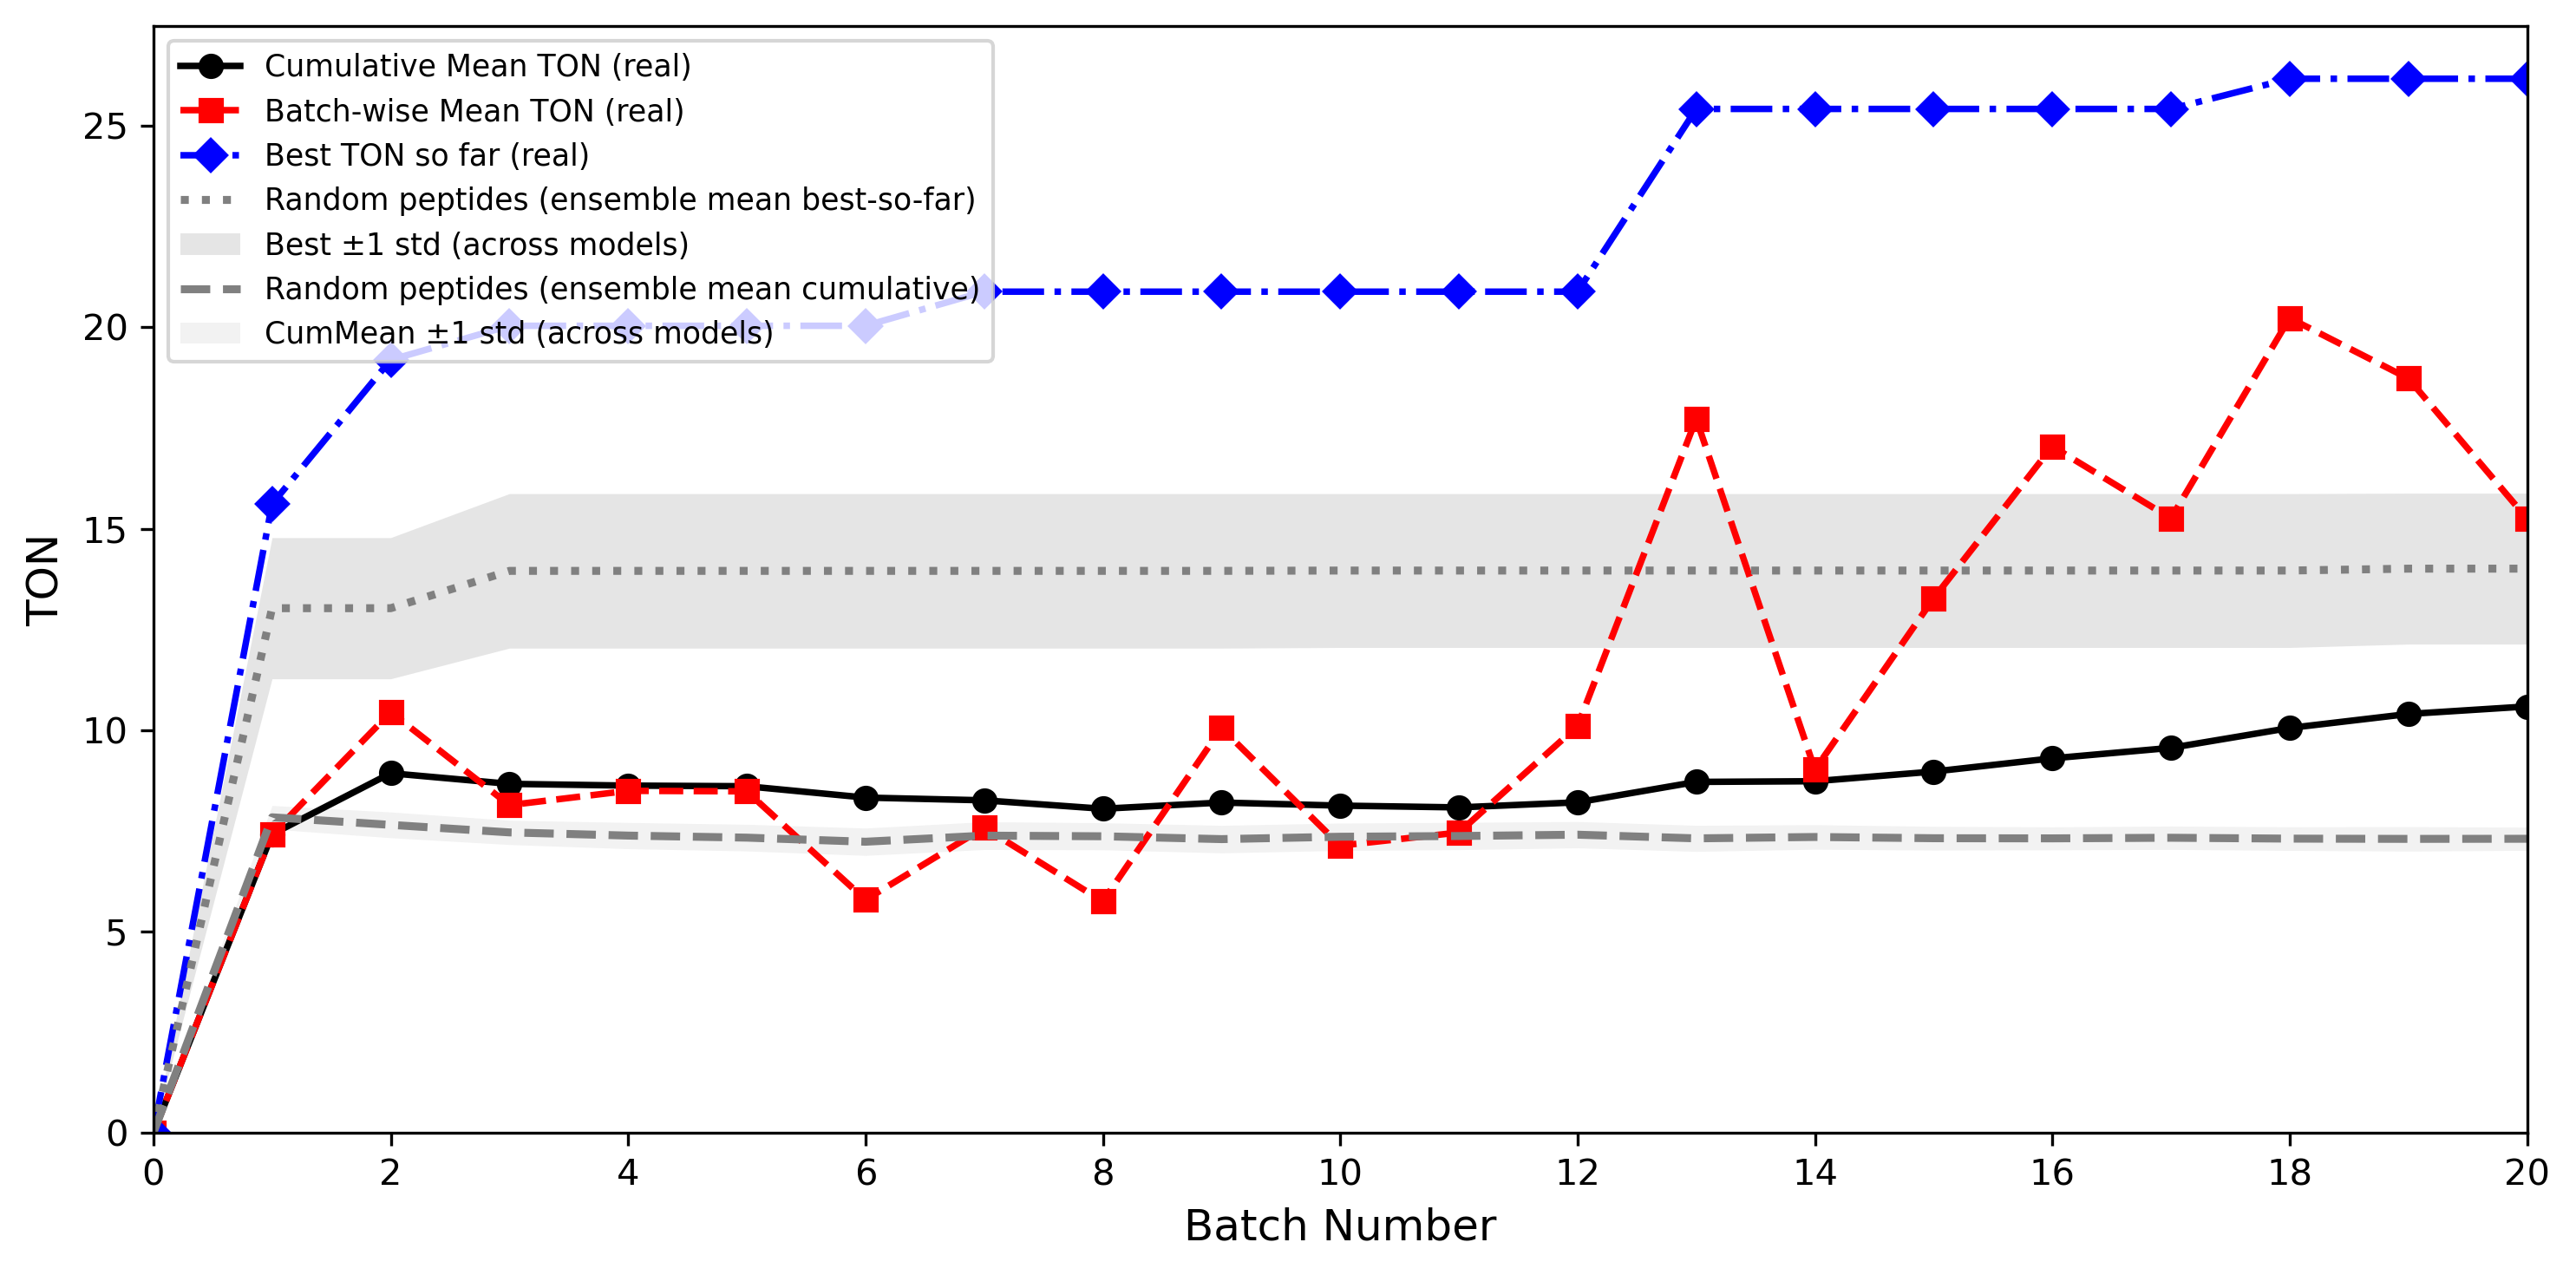

In [16]:
# choose which baseline curves to plot
best_mean = baseline["best_mean"]
best_std  = baseline["best_std"]

cum_mean  = baseline["cum_mean"]
cum_std   = baseline["cum_std"]

# ============================================================
# Plot: random baseline (best-so-far + cumulative mean), each with ±1 std across models
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

ax.plot(x, mean_ton_all,   marker='o', linestyle='-',  color='black', linewidth=1.8, markersize=6, label="Cumulative Mean TON (real)")
ax.plot(x, mean_ton_batch, marker='s', linestyle='--', color='red',   linewidth=1.8, markersize=6, label="Batch-wise Mean TON (real)")
ax.plot(x, best_ton_all,   marker='D', linestyle='-.', color='blue',  linewidth=1.8, markersize=6, label="Best TON so far (real)")
# Best-so-far
ax.plot(x, best_mean, linestyle=':', linewidth=2.2, color='gray',
        label="Random peptides (ensemble mean best-so-far)")
ax.fill_between(x, best_mean - best_std, best_mean + best_std,
                color='gray', alpha=0.20, linewidth=0, label="Best ±1 std (across models)")

# Cumulative mean
ax.plot(x, cum_mean, linestyle='--', linewidth=2.2, color='gray',
        label="Random peptides (ensemble mean cumulative)")
ax.fill_between(x, cum_mean - cum_std, cum_mean + cum_std,
                color='gray', alpha=0.10, linewidth=0, label="CumMean ±1 std (across models)")

ax.set_xlabel("Batch Number", fontsize=12)
ax.set_ylabel("TON", fontsize=12)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlim(0, len(x) - 1)
ax.set_ylim(bottom=0)
ax.legend(loc="upper left", fontsize='small')

plt.tight_layout()
plt.show()

In [19]:
pd.DataFrame(baseline).to_csv("random_baseline_from_models.csv")